# Automated product categorization for e-commerce
> Industries: e-commerce, delivery apps, marketplaces, many others

> Technologies and Tools: NLP, Computer Vision, Supervised Learning, Deep Learning, HTTP APIs, TensorFlow, Pytorch, Transformers, Spacy/NLTK, Docker.

Creating relevant tags and categories on products allow e-commerce companies (such as Amazon, Wayfair, eBay in the US, Mercado Libre, Dafiti in Latam, or ASOS.com and Zalando in Europe), and super apps and marketplaces (such as Instacart in the US, Rappi, Frubana, JOKR in Latam) to automatically categorize products whether those are new products uploaded by a user or seller products that need large-scale automated categorization. Automation on this subject not only saves time and manual effort but creates a taxonomy system that improves the process of a customer finding what they are looking for, improving their conversion metrics, and activating frictionless and engaging shopping experiences. In this project you will apply natural language processing to create a multi-label system able to classify e-commerce products automatically.


## 1. Download and evaluate the dataset

Start with EDA over our dataset. Get metrics about the number of products, unique categories, histogram of categories, etc. Consider that one product can belong to more than one category because there is a taxonomic structure.
Find the most common categories, using a histogram and removing all categories with a value less than 100. Use the categories above the threshold as the final categories and label every other below as a new “other” category.


In [47]:
import os
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import itertools
from collections import Counter
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import ToktokTokenizer
from nltk.stem import WordNetLemmatizer
import nltk
from wordcloud import WordCloud


### Getting the data



1.1. Download the datasets.

In [2]:
with open('datasets/categories.json') as file:
    categories_data = json.load(file)

with open('datasets/products.json', encoding='utf-8') as file:
    products_data = json.load(file)

Create dataframe with categories and products

In [3]:
categories_df = pd.DataFrame(categories_data)
products_df_init= pd.DataFrame(products_data)

Inspecting the dataframes


In [4]:
categories_df.shape

(4584, 4)

In [5]:
products_df_init.shape

(51646, 12)

In [6]:
categories_df.info

<bound method DataFrame.info of                      id                                   name  \
0          abcat0010000                             Gift Ideas   
1          abcat0020001                          Learning Toys   
2          abcat0020002                              DVD Games   
3          abcat0020004                           Unique Gifts   
4          abcat0100000                      TV & Home Theater   
...                 ...                                    ...   
4579  pcmcat86300050019           New Sony Blu-ray Disc Player   
4580  pcmcat86300050020          Movies Coming to Blu-ray Disc   
4581  pcmcat86500050000  Blu-ray Disc and DVD-Video Comparison   
4582  pcmcat87800050001                       Customer Service   
4583  pcmcat94300050028                              Birthdays   

                                                   path  \
0        [{'id': 'abcat0010000', 'name': 'Gift Ideas'}]   
1     [{'id': 'abcat0010000', 'name': 'Gift Ideas'},...  

In [7]:
column_names = categories_df.columns
print(column_names)

Index(['id', 'name', 'path', 'subCategories'], dtype='object')


In [8]:
categories_df.sample(5)

,id,name,path,subCategories
347,abcat0808002,Business Paper,"[{'id': 'pcmcat312300050015', 'name': 'Connect...",[]
1630,pcmcat188000050000,Setup & Training,"[{'id': 'pcmcat138100050018', 'name': 'Geek Sq...",[]
995,pcmcat140900050016,Canon,"[{'id': 'pcmcat128500050004', 'name': 'Name Br...","[{'id': 'pcmcat140900050017', 'name': 'Digital..."
3507,pcmcat334200050018,Juice Presses,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",[]
4337,pcmcat748300920853,Powersports Subwoofers,"[{'id': 'abcat0300000', 'name': 'Car Electroni...",[]


In [9]:
column_names = products_df_init.columns
print(column_names)

Index(['sku', 'name', 'type', 'price', 'upc', 'category', 'shipping',
       'description', 'manufacturer', 'model', 'url', 'image'],
      dtype='object')


In [10]:
products_df_init.sample(5)

,sku,name,type,price,upc,category,shipping,description,manufacturer,model,url,image
49093,9510576,Riot - League of Legends Game Card ($25) - Black,HardGood,25.00,799366646648,"[{'id': 'abcat0700000', 'name': 'Video Games'}...",0,Enhance the arena fighting gameplay experience,Riot,RIOT GAMES,http://www.bestbuy.com/site/riot-league-of-leg...,http://img.bbystatic.com/BestBuy_US/images/pro...
44218,8753108,j5 create - USB 3.0 Wormhole Switch DSS - White,HardGood,79.99,847626000966,"[{'id': 'abcat0500000', 'name': 'Computers & T...",0,Lets you control up to 2 computers with differ...,j5 create,JUC700,http://www.bestbuy.com/site/j5-create-usb-3-0-...,http://img.bbystatic.com/BestBuy_US/images/pro...
44445,8808216,Bosch - 500 Series 4.0 Cu. Ft. 15-Cycle High-E...,HardGood,1199.99,825225916864,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",,LED display with touch controls; ActiveDry sys...,Bosch,WTG86401UC,http://www.bestbuy.com/site/bosch-500-series-4...,http://img.bbystatic.com/BestBuy_US/images/pro...
44802,8849981,Niles - Cat-5 Stereo Audio Balun Connector,HardGood,59.99,760514012813,"[{'id': 'pcmcat139900050002', 'name': 'Magnoli...",0,From our expanded online assortment; designed ...,Niles,C5-A2,http://www.bestbuy.com/site/niles-cat-5-stereo...,http://img.bbystatic.com/BestBuy_US/images/pro...
701,1134168,Canon - PGI-1200 Ink Cartridge - Cyan,HardGood,13.99,013803238280,"[{'id': 'pcmcat312300050015', 'name': 'Connect...",0,Compatible with select Canon printers; cyan in...,Canon,9232B001,http://www.bestbuy.com/site/canon-pgi-1200-ink...,http://img.bbystatic.com/BestBuy_US/images/pro...


Creating a random number to check the values corresponding to that record in the products DF

In [11]:
random_number = random.randint(1, 51646)
random_number

47528

In [12]:
name_prod = products_df_init.loc[random_number, 'name']
print(name_prod)

Salton - Harley Pasternak 64-Oz. Blender - Black


In [13]:
first_description = products_df_init.loc[random_number, 'description']
print(first_description)

Knob and switch controls; 2HP motor with variable speed control; blend, crush, emulsify, chop, pur&#233;e and liquefy settings; 8 stainless steel blades; 2L BPA-free Tritan Vortex jar; 24-oz. on-the-go bottle


In [14]:
first_category = products_df_init.loc[random_number, 'category']
print(first_category)

[{'id': 'abcat0900000', 'name': 'Appliances'}, {'id': 'abcat0912000', 'name': 'Small Kitchen Appliances'}, {'id': 'abcat0912011', 'name': 'Blenders & Juicers'}, {'id': 'pcmcat194000050018', 'name': 'Blenders'}, {'id': 'pcmcat258900050003', 'name': 'Full-Size Blenders'}]


Analyzing the images of the products

In [15]:
first_image = products_df_init.loc[random_number, 'image']
print(first_image)

http://img.bbystatic.com/BestBuy_US/images/products/9296/9296233_rc.jpg


In [ ]:
# First, get the 'image' column from the DataFrame
image_column = products_df_init['image']

# Define a function to extract the file name from a URL
def extract_file_name(url):
    # We use a regular expression to extract the file name from the URL
    pattern = r"/([^/]+\.jpg)$"
    match = re.search(pattern, url)
    if match:
        return match.group(1)
    return None

# Then, apply the function to the 'image' column to obtain the file names
file_names = image_column.apply(extract_file_name)

# Now, count the number of unique file names to get the total number of images
total_images = file_names.nunique()

print("Total images:", total_images)


Total de imágenes: 51566


In [16]:
# Count the number of products without an image (empty cells or null values in the 'image' column)
products_without_image = products_df_init['image'].isna().sum()

# Count the number of downloaded images (non-empty cells) in the 'image' column
downloaded_images = products_df_init['image'].count()

# Print the results
print("Number of products without an image:", products_without_image)
print("Number of downloaded images:", downloaded_images)


Number of products without an image: 0
Number of downloaded images: 51646


In [17]:
# Get the count of duplicate images
duplicate_images = products_df_init.duplicated(subset='image').sum()

# Print the count of duplicate images
print("Number of duplicate images:", duplicate_images)


Number of duplicate images: 77


Creating a new dataframe with the name, category and description columns, which is what we are going to work with

In [18]:
# Seleccionar las columnas deseadas
selected_columns = ['name', 'category', 'description']
products_df = products_df_init[selected_columns].copy()

In [19]:
products_df.sample(5)

,name,category,description
7688,Army Rescue - PRE-OWNED - Nintendo Wii,"[{'id': 'abcat0700000', 'name': 'Video Games'}...","Command, cut and catch your way to victory"
19835,Targus - USB and HDMI Docking Station - Black,"[{'id': 'abcat0500000', 'name': 'Computers & T...","Compatible with select Windows, Mac and Androi..."
23618,Spigen - Slim Armor Case for Apple® iPhone® 6 ...,"[{'id': 'abcat0800000', 'name': 'Cell Phones'}...",SPIGEN Slim Armor Case for Apple iPhone 6 Plus...
12477,Yukon - Edge GS 2.7x50 Night Vision Binocular,"[{'id': 'abcat0400000', 'name': 'Cameras & Cam...","2.7x 50 mm - Water Proof, Fog Proof, Weather P..."
12068,Solo - Urban Convertible Laptop Briefcase Back...,"[{'id': 'abcat0500000', 'name': 'Computers & T...","Fits most laptops with up to a 15.6"" display; ..."


Breaking down the different categories and creating a new column with them

In [20]:
# Breaking down the different categories

def extract_categories(category_list):
    categories = []
    for category_dict in category_list:
        categories.append(category_dict['name'])
    return categories

# Apply the function to each row in the 'category' column and store the results in a new column:
products_df['extracted_categories'] = products_df['category'].apply(extract_categories)


In [21]:
print(products_df['extracted_categories'])

0        [Connected Home & Housewares, Housewares, Hous...
1        [Connected Home & Housewares, Housewares, Hous...
2        [Connected Home & Housewares, Housewares, Hous...
3        [Connected Home & Housewares, Housewares, Hous...
4        [Connected Home & Housewares, Housewares, Hous...
                               ...                        
51641    [Appliances, Appliance Parts & Accessories, Ai...
51642    [Appliances, Appliance Parts & Accessories, Va...
51643    [Computers & Tablets, Computer Accessories & P...
51644    [TV & Home Theater, Streaming Media Players, R...
51645     [Appliances, Small Kitchen Appliances, Toasters]
Name: extracted_categories, Length: 51646, dtype: object


In [23]:
# Breaking down the different subcategories
def sub_categories(category_list):
    sub_categories = []
    for category_dict in category_list:
        sub_categories.append(category_dict['name'])
    return sub_categories

# Apply the function to each row in the 'subCategories' column and store the results in a new column:
categories_df['sub_categories'] = categories_df['subCategories'].apply(sub_categories)


In [24]:
print(categories_df['sub_categories'])

0       [Capturing Photos & Videos, Listening to Digit...
1                                                      []
2                                                      []
3                                                      []
4       [TVs, Smart TVs & Devices, Projectors & Screen...
                              ...                        
4579    [Movies Coming to Blu-ray Disc, Blu-ray Disc a...
4580                                                   []
4581                                                   []
4582                                               [Help]
4583                                                   []
Name: sub_categories, Length: 4584, dtype: object


In [25]:
products_df.sample(5)


,name,category,description,extracted_categories
36748,Bower - 58mm Variable Neutral-Density Filter -...,"[{'id': 'abcat0400000', 'name': 'Cameras & Cam...",BOWER 58mm Variable Neutral-Density Filter: Co...,"[Cameras & Camcorders, Digital Camera Accessor..."
34309,T-Fal - OptiGrill Grill - Stainless-Steel/Black,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",Touch-panel interface; 6 cooking programs; fro...,"[Appliances, Small Kitchen Appliances, Electri..."
14814,BISSELL - DeepClean+ Antibacterial Cleaner - M...,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",Controls odor-causing bacteria; removes stains...,"[Appliances, Appliance Parts & Accessories, Va..."
1073,Discovery Kids - 0.3-Megapixel Digital Camera ...,"[{'id': 'abcat0400000', 'name': 'Cameras & Cam...","1.5"" LCDDigital image stabilizationAutofocusBu...","[Cameras & Camcorders, Digital Cameras, Point ..."
34585,La Cuisine - Cast-Iron Rectangular Covered Cas...,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",LA CUISINE Cast-Iron Rectangular Covered Casse...,"[Appliances, Small Kitchen Appliances, Cookwar..."


Checking the unique categories

Quantity of articles by category

In [26]:
#Quantity of articles by category
category_counts = products_df['extracted_categories'].value_counts()
print(category_counts)

[Video Games, Pre-Owned Games]                                                                                                                  3556
[Cell Phones, Cell Phone Accessories, Cell Phone Cases & Clips]                                                                                 1845
[Cell Phones, Cell Phone Accessories, iPhone Accessories, iPhone Cases & Clips]                                                                 1471
[Car Electronics & GPS, Car Installation Parts & Accessories, Car Audio Installation Parts, Deck Installation Parts, Dash Installation Kits]     739
[Appliances, Refrigerators, All Refrigerators]                                                                                                   689
                                                                                                                                                ... 
[Cameras & Camcorders, Digital Camera Accessories, Camera Batteries & Power, Camera Chargers & Adapters, C

Creating a histogram with the top 25 of the categories with the most associated products

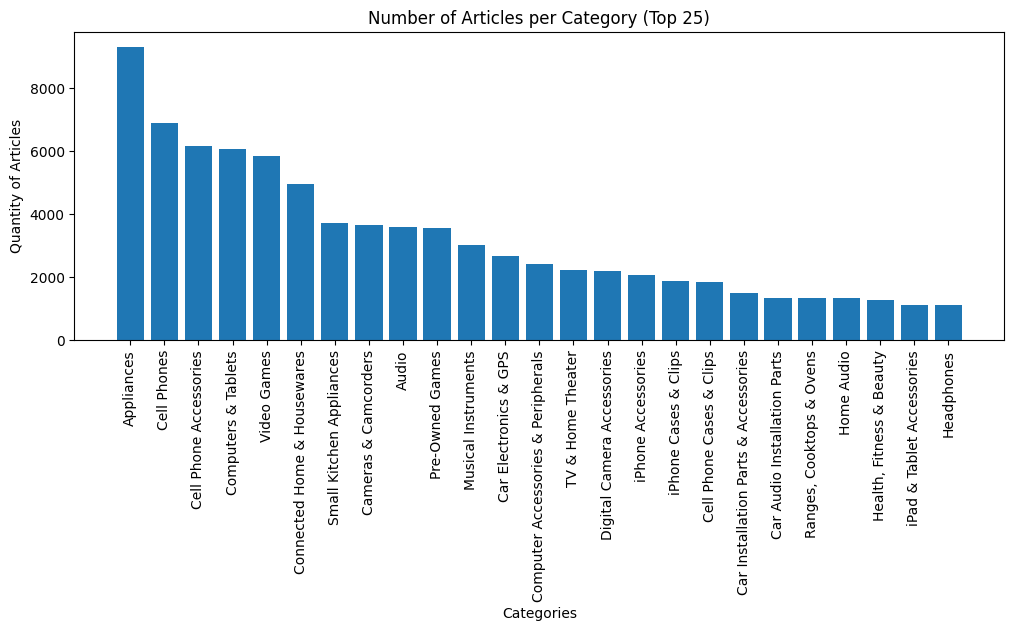

In [28]:
# Get all categories
all_categories = list(itertools.chain.from_iterable(products_df['extracted_categories']))

# Count the frequency of each category
category_counts = dict(Counter(all_categories))

# Sort categories by their frequency in descending order
sorted_categories = sorted(category_counts, key=category_counts.get, reverse=True)

# Take the top 25 categories with the highest occurrence
top_25_categories = {category: category_counts[category] for category in sorted_categories[:25]}

# Get category names and their respective counts
categories = list(top_25_categories.keys())
article_counts = list(top_25_categories.values())

# Create the bar chart
plt.figure(figsize=(12, 4))
plt.bar(categories, article_counts)
plt.xlabel('Categories')
plt.ylabel('Quantity of Articles')
plt.title('Number of Articles per Category (Top 25)')
plt.xticks(rotation=90)

# Display the chart
plt.show()


Number of categories with a single article and with less than 100, 10 y 1

In [30]:
# Get all categories
all_categories = list(itertools.chain.from_iterable(products_df['extracted_categories']))

# Count the frequency of each category
category_counts = dict(Counter(all_categories))

# Count the number of categories with only one article
single_article_categories = sum(1 for count in category_counts.values() if count == 1)

# Count the number of categories with less than 100 articles
article_categories_100 = sum(1 for count in category_counts.values() if count < 100)

# Count the number of categories with less than 10 articles
article_categories_10 = sum(1 for count in category_counts.values() if count < 10)

print("Number of categories with only one article:", single_article_categories)
print("Number of categories with less than 100 articles:", article_categories_100)
print("Number of categories with less than 10 articles:", article_categories_10)


Number of categories with only one article: 243
Number of categories with less than 100 articles: 1534
Number of categories with less than 10 articles: 796


In [31]:
# Count the number of categories with less than 100 articles
article_categories_100 = sum(1 for count in category_counts.values() if count < 100)

print("Number of categories with less than 100 articles:", article_categories_100)


Number of categories with less than 100 articles: 1534


Replacing the categories with less than 100 by Other

In [32]:
# Get categories with less than 100 articles
categories_less_than_100_articles = [category for category, count in category_counts.items() if count < 100]



In [34]:
# Function to find the category to which a subcategory belongs
def find_category_by_subcategory(subcategory):
    for _, row in categories_df.iterrows():
        if subcategory in row['sub_categories']:
            return row['name']
    return None

# Let's assume you want to search for the category of a random subcategory
subcategory_to_find = random.choice(categories_less_than_100_articles)
category_found = find_category_by_subcategory(subcategory_to_find)

if category_found is not None:
    print(f"The subcategory '{subcategory_to_find}' belongs to the category '{category_found}'.")
else:
    print(f"The subcategory '{subcategory_to_find}' was not found in the DataFrame.")


The subcategory 'Powerline Networking' belongs to the category 'D-Link'.


In [35]:
# Create a dictionary to store the results
categories_by_subcategories_total = {}

# Iterate over the categories_less_than_100_articles list and find the category for each subcategory
for subcategory in categories_less_than_100_articles:
    category_belongs_to = find_category_by_subcategory(subcategory)
    categories_by_subcategories_total[subcategory] = category_belongs_to


In [36]:
categories_by_subcategories_total

{'Alkaline Batteries': 'Batteries & Power',
 'Carfi Instore Only': None,
 'Specialty Batteries': 'Batteries & Power',
 'In-Store Only': None,
 'Cordless Phone Batteries': 'Telephone Accessories',
 'Sound Recording Software': 'Recording Equipment',
 'Music Memorabilia': 'TV, Movie & Character Toys',
 'Keyboard Accessories': 'Musical Instrument Accessories',
 'More Pop Culture Merchandise': 'TV, Movie & Character Toys',
 'Live Sound Speakers': 'Microphones & Live Sound',
 'Speaker Monitors': 'Live Sound Speakers',
 'Audio Interfaces': 'Recording Equipment',
 'Other Musical Instrument Accessories': 'Musical Instrument Accessories',
 'Midi Keyboards & Controllers': 'Keyboards',
 'DJ Equipment Accessories': 'Musical Instrument Accessories',
 'Recording Furniture & Stands': 'Recording Equipment',
 'Recording & Music Stands': 'Recording Furniture & Stands',
 'Dynamic': 'Microphones',
 'DJ Console Systems': 'DJ & Lighting Equipment',
 'Games, Puzzles & Cards': 'Toys, Games & Drones',
 'Puzzles

In [37]:
no_category_count = 0

# Create a list to store subcategories without a category
subcategories_without_category = []

# Print the results
for subcategory, category_belongs_to in categories_by_subcategories_total.items():
    if category_belongs_to is not None:
        print(f"The subcategory '{subcategory}' belongs to the category '{category_belongs_to}'.")
    else:
        no_category_count += 1
        subcategories_without_category.append(subcategory)
        print(f"The subcategory '{subcategory}' was not found in the DataFrame.")


The subcategory 'Alkaline Batteries' belongs to the category 'Batteries & Power'.
The subcategory 'Carfi Instore Only' was not found in the DataFrame.
The subcategory 'Specialty Batteries' belongs to the category 'Batteries & Power'.
The subcategory 'In-Store Only' was not found in the DataFrame.
The subcategory 'Cordless Phone Batteries' belongs to the category 'Telephone Accessories'.
The subcategory 'Sound Recording Software' belongs to the category 'Recording Equipment'.
The subcategory 'Music Memorabilia' belongs to the category 'TV, Movie & Character Toys'.
The subcategory 'Keyboard Accessories' belongs to the category 'Musical Instrument Accessories'.
The subcategory 'More Pop Culture Merchandise' belongs to the category 'TV, Movie & Character Toys'.
The subcategory 'Live Sound Speakers' belongs to the category 'Microphones & Live Sound'.
The subcategory 'Speaker Monitors' belongs to the category 'Live Sound Speakers'.
The subcategory 'Audio Interfaces' belongs to the category '

In [38]:
# Print the total number of subcategories without a found category
print(f"Total subcategories without a found category: {no_category_count}")

# Print the list of subcategories without a category
print("Subcategories without a category:")
for subcategory in subcategories_without_category:
    print(subcategory)

Total subcategories without a found category: 71
Subcategories without a category:
Carfi Instore Only
In-Store Only
Exclusives
Gadgets
Kinect Games
PC Gaming Hardware
Fans & Cooling Kits
Outlet Store
XBox_Buy2Get1_20130616
Wet/Dry Vacuums
MP Pending
Beverage Coolers & Dispensers
Beverage & Wine Coolers
Xbox 360 Collectibles
H/VG_X360/Games/B2G1_20130602
Sleep & Stress Relief
Other Product Categories
Resistance Bands
Bottles & Feeding
Furniture
Personal Monitoring Devices
Car Accessories
Surge Protectors & Power Management
iPhone Appcessories¿ Products
Wireless Gaming Devices
Point & Shoot Camera Cases
SteelSeries Mice
MP Exclusives
DSLR Camera Chargers
Built-In HD Radio Decks
8mm Videotapes
Infrared Filters
AV Surge Protection
Custom Parts
iPhone Chargers & Adapters
SteelSeries Headsets
Gaming Audio
Geek Squad Services
Video Switchers
Wireless Systems & Cameras
Bunk Beds & Mattresses
Karaoke Software
Freestanding Gas Ranges
GameCube
Analog Audio Cables
Double Electric Wall Ovens
Single

In [39]:
# Separate categories with a value of "None" from the rest of the elements
categories_less_than_30_final = {}
categories_by_subcategories = {}

for category, subcategory in categories_by_subcategories_total.items():
    if subcategory is None:
        categories_less_than_30_final[category] = subcategory
    else:
        categories_by_subcategories[category] = subcategory

print("Categories with value 'None':")
print(categories_less_than_30_final)


Categories with value 'None':
{'Carfi Instore Only': None, 'In-Store Only': None, 'Exclusives': None, 'Gadgets': None, 'Kinect Games': None, 'PC Gaming Hardware': None, 'Fans & Cooling Kits': None, 'Outlet Store': None, 'XBox_Buy2Get1_20130616': None, 'Wet/Dry Vacuums': None, 'MP Pending': None, 'Beverage Coolers & Dispensers': None, 'Beverage & Wine Coolers': None, 'Xbox 360 Collectibles': None, 'H/VG_X360/Games/B2G1_20130602': None, 'Sleep & Stress Relief': None, 'Other Product Categories': None, 'Resistance Bands': None, 'Bottles & Feeding': None, 'Furniture': None, 'Personal Monitoring Devices': None, 'Car Accessories': None, 'Surge Protectors & Power Management': None, 'iPhone Appcessories¿ Products': None, 'Wireless Gaming Devices': None, 'Point & Shoot Camera Cases': None, 'SteelSeries Mice': None, 'MP Exclusives': None, 'DSLR Camera Chargers': None, 'Built-In HD Radio Decks': None, '8mm Videotapes': None, 'Infrared Filters': None, 'AV Surge Protection': None, 'Custom Parts': No

In [40]:
categories_by_subcategories

{'Alkaline Batteries': 'Batteries & Power',
 'Specialty Batteries': 'Batteries & Power',
 'Cordless Phone Batteries': 'Telephone Accessories',
 'Sound Recording Software': 'Recording Equipment',
 'Music Memorabilia': 'TV, Movie & Character Toys',
 'Keyboard Accessories': 'Musical Instrument Accessories',
 'More Pop Culture Merchandise': 'TV, Movie & Character Toys',
 'Live Sound Speakers': 'Microphones & Live Sound',
 'Speaker Monitors': 'Live Sound Speakers',
 'Audio Interfaces': 'Recording Equipment',
 'Other Musical Instrument Accessories': 'Musical Instrument Accessories',
 'Midi Keyboards & Controllers': 'Keyboards',
 'DJ Equipment Accessories': 'Musical Instrument Accessories',
 'Recording Furniture & Stands': 'Recording Equipment',
 'Recording & Music Stands': 'Recording Furniture & Stands',
 'Dynamic': 'Microphones',
 'DJ Console Systems': 'DJ & Lighting Equipment',
 'Games, Puzzles & Cards': 'Toys, Games & Drones',
 'Puzzles': 'Games, Puzzles & Cards',
 'Wii Games': 'Wii',
 'D

In [41]:
# Function to rename subcategories to their parent category if applicable
def rename_subcategory(category):
    if category in categories_less_than_100_articles and category in categories_by_subcategories:
        return categories_by_subcategories[category]
    else:
        return category

# Apply the function to the 'extracted_categories' column
products_df['extracted_categories'] = products_df['extracted_categories'].apply(lambda cats: [rename_subcategory(cat) for cat in cats])


In [42]:
products_df.sample(5)

,name,category,description,extracted_categories
47894,Amazon - Standing Protective Case for Fire HD ...,"[{'id': 'abcat0500000', 'name': 'Computers & T...",Compatible with Fire HD 6; polyurethane materi...,"[Computers & Tablets, iPad & Tablet Accessorie..."
45470,Sony - $20 PlayStation Network Card,"[{'id': 'abcat0700000', 'name': 'Video Games'}...",Enhance your enjoyment of your PlayStation system,"[Video Games, Video Games, PlayStation 3, Play..."
25301,weBoost - eqo Cell Phone Signal Booster - Black,"[{'id': 'abcat0800000', 'name': 'Cell Phones'}...",Supports most carriers; works with most cell p...,"[Cell Phones, Cell Phone Accessories, Cell Pho..."
10668,"Bosch - Recirculation Module for Bosch 30"" and...","[{'id': 'abcat0900000', 'name': 'Appliances'},...","BOSCH Recirculation Module for Bosch 30"" and 3...","[Appliances, Appliance Parts & Accessories, Ra..."
50315,Elixir - Nanoweb Phosphor Bronze Light Acousti...,"[{'id': 'abcat0207000', 'name': 'Musical Instr...",Compatible with most acoustic guitars; phospho...,"[Musical Instruments, Musical Instrument Acces..."


In [43]:
# Get all categories
all_categories = list(itertools.chain.from_iterable(products_df['extracted_categories']))

# Count the frequency of each category
category_counts = dict(Counter(all_categories))

# Count the number of categories with less than 100 articles
article_categories_100 = sum(1 for count in category_counts.values() if count < 100)

print("Number of categories with less than 100 articles:", article_categories_100)


Number of categories with less than 100 articles: 317


In [44]:
# Get categories with less than 100 articles
new_categories_less_than_100_articles = [category for category, count in category_counts.items() if count < 100]


In [45]:
# Count how many None values are in the 'extracted_categories' column
none_count = products_df['extracted_categories'].isnull().sum()

print(f"The 'extracted_categories' column has {none_count} None values.")


The 'extracted_categories' column has 0 None values.


In [48]:
# Get categories with fewer than 100 articles
categories_less_than_100_articles = [category for category, count in category_counts.items() if count < 100]

# Get categories with more than 100 articles
categories_more_than_100_articles = [category for category, count in category_counts.items() if count > 100]

# Get all unique categories (without None values)
all_categories = products_df['extracted_categories'].explode().unique()
all_categories = all_categories[pd.notnull(all_categories)]

# Get phrases (categories) for training the Word2Vec model
training_phrases = [' '.join(category.split()) for category in all_categories]

# Create a TF-IDF vectorizer to represent categories as vectors
tfidf_vectorizer = TfidfVectorizer(analyzer='word', lowercase=False, min_df=1, stop_words='english')
category_vectors = tfidf_vectorizer.fit_transform(training_phrases)

# Function to calculate similarity between two categories
def calculate_similarity(category1, category2):
    if category1 is None or category2 is None:
        return 0.0  # Return low similarity if either category is None

    index_category1 = all_categories.tolist().index(category1)
    if category2 not in all_categories:
        return 0.0  # Return low similarity if category2 is not in all_categories
    index_category2 = all_categories.tolist().index(category2)
    vector_category1 = category_vectors[index_category1]
    vector_category2 = category_vectors[index_category2]
    similarity = cosine_similarity(vector_category1, vector_category2)[0][0]
    return similarity

# Define a reference category
random_category = random.choice(categories_less_than_100_articles)
reference_category = random_category

# Calculate similarity between the reference category and all other valid categories
similarities = {}
for category in categories_more_than_100_articles:
    similarity = calculate_similarity(reference_category, category)
    similarities[category] = similarity

# Sort categories by similarity in descending order
similar_categories = sorted(similarities, key=similarities.get, reverse=True)

# Print the most similar categories to the reference category
print(f"Reference category: {reference_category}")
for category in similar_categories[:5]:
    print(f"Similar category: {category}, Similarity: {similarities[category]}")


Reference category: Music (CDs & Vinyl)
Similar category: Sheet Music, Similarity: 0.31535436326785793
Similar category: Movies & Music, Similarity: 0.3037576641048589
Similar category: Sheet Music & DVDs, Similarity: 0.2547991967142051
Similar category: Connected Home & Housewares, Similarity: 0.0
Similar category: Housewares, Similarity: 0.0


In [49]:
# Dictionary to store the category with the highest similarity for each category with fewer than 100 articles
highest_similarity_for_less_than_100 = {}

# Calculate the category with the highest similarity for each category with fewer than 100 articles
for category_less_than_100 in categories_less_than_100_articles:
    similarities = {}
    for category_more_than_100 in categories_more_than_100_articles:
        similarity = calculate_similarity(category_less_than_100, category_more_than_100)
        similarities[category_more_than_100] = similarity
    # Get the category with the highest similarity from those with more than 100 articles
    category_highest_similarity = max(similarities, key=similarities.get)
    highest_similarity_for_less_than_100[category_less_than_100] = category_highest_similarity

# Print the results
for category_less_than_100, category_highest_similarity in highest_similarity_for_less_than_100.items():
    print(f"Category with fewer than 100 articles: {category_less_than_100}")
    print(f"Category with more than 100 articles and highest similarity: {category_highest_similarity}")
    print()


Category with fewer than 100 articles: Carfi Instore Only
Category with more than 100 articles and highest similarity: Connected Home & Housewares

Category with fewer than 100 articles: In-Store Only
Category with more than 100 articles and highest similarity: In-Wall & In-Ceiling Speakers

Category with fewer than 100 articles: Live Sound Speakers
Category with more than 100 articles and highest similarity: Microphones & Live Sound

Category with fewer than 100 articles: Recording Furniture & Stands
Category with more than 100 articles and highest similarity: TV Stands, Mounts & Furniture

Category with fewer than 100 articles: Games, Puzzles & Cards
Category with more than 100 articles and highest similarity: Video Games

Category with fewer than 100 articles: Digital SLR Cameras
Category with more than 100 articles and highest similarity: Digital Cameras

Category with fewer than 100 articles: Karaoke
Category with more than 100 articles and highest similarity: Connected Home & Hou

In [50]:

# Function to rename subcategories to their superior category if applicable
def rename_subcategory(category):
    if category in highest_similarity_for_less_than_100:
        return highest_similarity_for_less_than_100[category]
    else:
        return category

# Apply the function to the 'extracted_categories' column
products_df['extracted_categories'] = products_df['extracted_categories'].apply(lambda cats: [rename_subcategory(cat) for cat in cats])


In [51]:
products_df.sample(5)

,name,category,description,extracted_categories
43694,Maytag - 6.2 Cu. Ft. Self-Cleaning Freestandin...,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",AquaLift cleaning technology; 5 elements; 100-...,"[Appliances, Ranges, Cooktops & Ovens, Ranges,..."
11031,Chief - 1U Sliding Shelf - Black,"[{'id': 'abcat0100000', 'name': 'TV & Home The...",Connects to most front and rear rack rails tha...,"[TV & Home Theater, TV Stands, Mounts & Furnit..."
39860,Apple - iPhone 6 16GB - Silver (AT&T),"[{'id': 'abcat0800000', 'name': 'Cell Phones'}...",4.7-inch Retina HD displayA8 chip with 64-bit ...,"[Cell Phones, All Cell Phones with Plans]"
24812,VOLO - Hard Shell Case for Apple® iPhone® 6 an...,"[{'id': 'abcat0800000', 'name': 'Cell Phones'}...",VOLO Hard Shell Case for Apple iPhone 6 and 6s...,"[Cell Phones, Cell Phone Accessories, iPhone A..."
33056,Cokin - P Series 82mm Adapter Ring,"[{'id': 'abcat0400000', 'name': 'Cameras & Cam...",COKIN P Series 82mm Adapter Ring: Fits Cokin P...,"[Cameras & Camcorders, Digital Camera Accessor..."


In [52]:
# Get all categories
all_categories = list(itertools.chain.from_iterable(products_df['extracted_categories']))

# Count the frequency of each category
category_counts = dict(Counter(all_categories))

# Count the number of categories with fewer than 10 articles
categories_less_than_100 = sum(1 for count in category_counts.values() if count < 100)

print("Number of categories with fewer than 100 articles:", categories_less_than_100)


Number of categories with fewer than 100 articles: 0


In [53]:
# Function to check if there are repeated categories in a list of categories
def has_duplicate_categories(categories):
    return len(categories) != len(set(categories))

# Apply the function to the 'extracted_categories' column and create a new column 'duplicate_categories'
products_df['duplicate_categories'] = products_df['extracted_categories'].apply(has_duplicate_categories)

# Display a sample of the DataFrame
print(products_df.sample(5))


                                                    name  \
44121  Frigidaire - Gallery Custom-Flex Bin for Selec...   
43815                       Dragon Dictate for Mac - Mac   
34434  Barska - Blackhawk 20-60 x 70 Spotting Scope -...   
37215        Resident Evil 6 — PRE-OWNED - PlayStation 3   
1805   Frigidaire - SALAV Performance Series Upright ...   

                                                category  \
44121  [{'id': 'abcat0900000', 'name': 'Appliances'},...   
43815  [{'id': 'pcmcat352500050020', 'name': 'Voice R...   
34434  [{'id': 'abcat0400000', 'name': 'Cameras & Cam...   
37215  [{'id': 'abcat0700000', 'name': 'Video Games'}...   
1805   [{'id': 'abcat0900000', 'name': 'Appliances'},...   

                                             description  \
44121  Compatible with Frigidaire Gallery refrigerato...   
43815  Speech recognition makes it easy to transcribe...   
34434  From our expanded online assortment; 20-60x ma...   
37215  Chris Redfield and Leon S. Kenn

In [54]:
# Count the number of cases with duplicate categories (True) and non-duplicate categories (False)
num_duplicate_categories = products_df['duplicate_categories'].value_counts()

# Print the results
print("Number of cases with duplicate categories:")
print(num_duplicate_categories)


Number of cases with duplicate categories:
False    31986
True     19660
Name: duplicate_categories, dtype: int64


In [55]:
# Function to remove duplicate categories in a list of categories
def remove_duplicate_categories(categories):
    return list(set(categories))

# Apply the function to the 'extracted_categories' column and replace the original values
products_df['extracted_categories'] = products_df['extracted_categories'].apply(remove_duplicate_categories)



In [56]:
# Function to check if there are duplicate categories in a list of categories
def has_duplicate_categories(categories):
    return len(categories) != len(set(categories))

# Apply the function to the 'extracted_categories' column and create a new column 'duplicate_categories'
products_df['duplicate_categories'] = products_df['extracted_categories'].apply(has_duplicate_categories)


In [57]:
products_df.sample(5)

,name,category,description,extracted_categories,duplicate_categories
47190,Niles - Cat-5 A/V and Stereo Balun Connector,"[{'id': 'abcat0200000', 'name': 'Audio'}, {'id...",From our expanded online assortment; designed ...,"[Home Audio Accessories, Speaker Accessories, ...",False
14196,"Wharfedale - WH-D10 10"" 300W Powered Subwoofer...","[{'id': 'abcat0200000', 'name': 'Audio'}, {'id...","300W maximum power; built-in amplifier; 10"" lo...","[Home Audio, Speakers, Audio]",False
49301,Midland - Window Mount CB Antenna for Select M...,"[{'id': 'abcat0300000', 'name': 'Car Electroni...",From our expanded online assortment; compatibl...,"[Car Audio, Car Electronics & GPS]",False
27817,LifeProof - Fre Protective Waterproof Case for...,"[{'id': 'abcat0800000', 'name': 'Cell Phones'}...",Compatible with Apple iPhone 6 Plus and 6s Plu...,"[Cell Phone Cases & Clips, Cell Phones, Cell P...",False
16584,DJI - Part 2 Propeller Guards for Select Phant...,"[{'id': 'pcmcat252700050006', 'name': 'Toys, G...",Designed for select Phantom 3 series quadcopte...,"[Drones & Accessories, Toys, Games & Drones, C...",False


In [58]:
# Count the number of cases with duplicate categories (True) and non-duplicate categories (False)
num_duplicate_categories = products_df['duplicate_categories'].value_counts()

# Print the results
print("Number of cases with duplicate categories:")
print(num_duplicate_categories)


Number of cases with duplicate categories:
False    51646
Name: duplicate_categories, dtype: int64


Checking the number of different categories left after renaming those less than 100

In [59]:
# Get all categories
all_categories = [cat for category_list in products_df['extracted_categories'] for cat in category_list]

# Get unique categories
unique_categories = set(all_categories)

# Count the number of unique categories
num_unique_categories = len(unique_categories)

# Display the number of unique categories
print(f"The number of unique categories is: {num_unique_categories}")


The number of unique categories is: 273


In [60]:
products_df.sample(5)

,name,category,description,extracted_categories,duplicate_categories
2315,My Baby: First Steps - PRE-OWNED - Nintendo Wii,"[{'id': 'abcat0700000', 'name': 'Video Games'}...","Teach a baby to walk, talk and play","[Video Games, Pre-Owned Games]",False
40494,Oster - Tall Power Pierce Can Opener - Silver,"[{'id': 'abcat0900000', 'name': 'Appliances'},...",Power Pierce cutting mechanism; contemporary d...,"[Appliances, Kitchen Gadgets, Small Kitchen Ap...",False
13568,Marantz - 160W 2.0-Ch. Integrated Amplifier - ...,"[{'id': 'abcat0200000', 'name': 'Audio'}, {'id...",High-speed instantaneous-current power supply;...,"[Receivers & Amplifiers, Home Audio, Yamaha, A...",False
9281,Sima - 4-Pair Speaker Selector - Black,"[{'id': 'abcat0200000', 'name': 'Audio'}, {'id...",SIMA 4-Pair Speaker Selector: Supports up to 4...,"[Home Audio Accessories, Speaker Accessories, ...",False
2896,Key Digital - Champion Series HDMI-to-Dual Cat...,"[{'id': 'abcat0100000', 'name': 'TV & Home The...",KEY DIGITAL Champion Series HDMI-to-Dual Cat-5...,"[TV & Home Theater, TV & Home Theater Accessor...",False


## 2. Create a training dataset

Implement the cleaning step to remove non-alphabetical characters, punctuation, stop words, etc. and encapsulate all of them into a preprocessing function. Use this function to clean the name and description of products, because you will use them as input to our system.
Create your dataset in S3 and save cleaned text with category information.


Unifying the Name and Description columns

In [61]:
def unify_phrases(row):
    name = row['name']
    description = row['description']

    # Check if values are None and handle them appropriately
    if name is None:
        name = ''
    if description is None:
        description = ''

    words = name.split() + description.split()
    unified_words = ' '.join(words)
    return unified_words

# Apply the function to each row of the DataFrame
products_df['Information'] = products_df.apply(unify_phrases, axis=1)


In [62]:
# Select the desired columns
selected_columns = ['Information', 'extracted_categories']
products_df = products_df[selected_columns].copy()

In [63]:
products_df.sample(15)

,Information,extracted_categories
37353,PhoneSuit - Elite External Battery Case for Ap...,"[iPhone Cases & Clips, iPhone Accessories, Cel..."
3013,FoodSaver - V2244 Vacuum Sealer - Black Crush-...,"[Appliances, Specialty Appliances, Small Kitch..."
7286,Sony - Alpha a7 Full-Frame Mirrorless Camera w...,"[Cameras & Camcorders, Digital Cameras, Mirror..."
17320,Frigidaire - 7.0 Cu. Ft. 8-Cycle High-Efficien...,"[Appliances, Electric Dryers, Dryers, Washers ..."
13173,WD - My Cloud EX4100 24TB 4-Bay External Netwo...,"[Networking & Wireless, Personal Care & Beauty..."
1651,DENAQ - AC Power Adapter and Charger for Selec...,"[Computers & Tablets, Laptop Chargers & Adapte..."
8805,Xerox - Phaser Black-and-White Laser Printer -...,"[All Printers, Office Electronics, Connected H..."
901,"Definitive Technology - 4-1/2"" Center-Channel ...","[Home Audio, Speakers, Audio]"
51564,LeapFrog - MAXX PLA Filament 1.65 lbs. - Brill...,"[Office & School Supplies, 3D Printer Filament..."
39651,"KitchenAid - 30"" Built-In Gas Cooktop - White ...","[Appliances, Cooktops, Ranges, Cooktops & Ovens]"


Starting data cleanup:
Lowercase: It is good practice to convert all text to lowercase to avoid duplicate issues due to differences in capitalization.
Elimination of stop words (stop words): Stop words are common words that do not add much meaning to text analysis, such as articles, pronouns, and prepositions. You can remove these words using the NLTK (Natural Language Toolkit) library in Python
Lematization or Stemming: You can apply lemmatization or stemming techniques to reduce words to their base form and eliminate morphological variations. This can help group words and reduce the dimensionality of the text.

In [64]:
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Tokenization using ToktokTokenizer
    tokenizer = ToktokTokenizer()
    text = ' '.join(tokenizer.tokenize(' '.join(words)))

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

# Apply the preprocessing function to the 'Information' column
products_df['Information'] = products_df['Information'].apply(preprocess_text)



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Modeler\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Modeler\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [65]:
products_df.sample(15)

,Information,extracted_categories
33488,lego hobbit preowned xbox one join favorite ch...,"[Video Games, Pre-Owned Games]"
32893,best buy gc 50 gift earth gift card perfect gi...,[Best Buy Gift Cards]
888,secur mini solar cell phone charger greenblack...,"[Portable Chargers/Power Packs, Cell Phone Bat..."
41300,frigidaire spacewise upright freezer basket wh...,"[Appliances, Appliance Parts & Accessories, Re..."
8305,gopro skeleton housing clearblack compatible h...,"[Digital Camera Accessories, Connected Home & ..."
32078,celestron nexstar rolling carrying case celest...,"[Cameras & Camcorders, Binoculars, Telescopes ..."
50752,garmin forerunner 920xt multisport gps watch b...,"[Health, Fitness & Beauty, Fitness & GPS Watches]"
27226,onstage 2tier keyboard stand black expanded on...,"[TV Stands, Mounts & Furniture, Recording Equi..."
6747,chase felix meet felicity preowned nintendo d ...,"[Video Games, Pre-Owned Games]"
27794,best buy gc 15 gadget lover unite gift card pe...,[Best Buy Gift Cards]


Count occurrences of "X" and "X box" in the "name" and "description" columns a to determine if single letter words are removed

In [66]:
# Count occurrences of "X" in the 'Information' column
description_count = products_df['Information'].str.count("x").sum()

# Count occurrences of "X box" in the 'Information' column
description_count1 = products_df['Information'].str.count("x box").sum()

print("Occurrences of 'x' in 'Information':", description_count)
print("Occurrences of 'x box' in 'Information':", description_count1)


Occurrences of 'x' in 'Information': 38328
Occurrences of 'x box' in 'Information': 0


Eliminating words made up of a single letter

In [67]:
# Removing single-letter words from the 'Information' column
products_df['Information'] = products_df['Information'].apply(lambda x: ' '.join([word for word in x.split() if len(word) > 1]))

In [68]:
products_df.sample(5)

,Information,extracted_categories
17739,pny 64gb usb 30 type flash drive silver retrac...,"[Computers & Tablets, USB Flash Drives, Comput..."
572,clive barker jericho preowned xbox 360 enter h...,"[Video Games, Pre-Owned Games]"
42061,exofab gel case apple iphone plus white exofab...,"[iPhone Cases & Clips, iPhone Accessories, Cel..."
82,american dj par 46 kit black expanded online a...,"[DJ & Lighting Equipment, Musical Instruments]"
8679,brother ds820w wireless mobile scanner white b...,"[Connected Home & Housewares, Computer Accesso..."


Text length: Calculate the length (number of characters) of the 'Information' column to get an idea of the length of the texts in your dataset

In [69]:
# Length of the 'Information' column
products_df['characters_length'] = products_df['Information'].apply(lambda x: len(x))

# Descriptive statistics of the lengths
print(products_df['characters_length'].describe())


count    51646.000000
mean       163.446966
std         58.113395
min         20.000000
25%        121.000000
50%        166.000000
75%        206.000000
max        398.000000
Name: characters_length, dtype: float64


Number of words: Calculate the number of words in the 'Information' column to get an idea of the length of the texts in your dataset

In [70]:
# Number of words in the 'Information' column
products_df['word_count'] = products_df['Information'].apply(lambda x: len(x.split()))

# Descriptive statistics of the word counts
print(products_df['word_count'].describe())


count    51646.000000
mean        22.810072
std          8.071618
min          3.000000
25%         17.000000
50%         23.000000
75%         28.000000
max         61.000000
Name: word_count, dtype: float64


In [71]:
products_df.sample(5)

,Information,extracted_categories,characters_length,word_count
14743,onechanbara zii chaos preowned playstation sav...,"[Video Games, Pre-Owned Games]",89,11
5970,microsoft arc touch surface edition mouse dark...,"[Computers & Tablets, Computer Accessories & P...",157,20
33131,ue roll wireless bluetooth speaker reef blueto...,"[Audio, Bluetooth & Wireless Speakers]",190,18
24747,keurig k425 brewer vintage red 24 color touch ...,"[Appliances, Small Kitchen Appliances, Coffee,...",127,17
13299,promounts flat curved adhesive mount 6count bl...,"[Cameras & Camcorders, Action Camcorder Access...",181,26


Common Word Analysis: Identify the most common words in the 'name' and 'description' columns to get an idea of the most frequently used terms.

In [72]:
# Combine all words in the 'Information' column and split them
information_words = ' '.join(products_df['Information']).split()

# Count the occurrences of each word
information_word_counts = Counter(information_words)

# Get the most common words
top_information_words = information_word_counts.most_common(15)

# Print the most common words
print('Most common words:')
for word, count in top_information_words:
    print(f'{word}: {count}')



Most common words:
black: 16206
compatible: 15622
apple: 10289
design: 8762
case: 7924
iphone: 6858
phone: 5780
control: 5733
power: 5486
select: 5454
camera: 5356
material: 5116
samsung: 4965
cell: 4738
white: 4520


Eliminating the colors, considering that they do not provide relevant information about the possible category and compatible word appears more than 15,000 times

In [73]:
# List of colors to remove and the common word 'compatible' which appeared more than 15,000 times
colors = ['red', 'blue', 'green', 'yellow', 'black', 'white', 'silver', 'gold', 'purple', 'pink', 'orange', 'compatible']  # Add the colors you want to remove

# Function to remove colors from text
def remove_colors(text):
    for color in colors:
        # Build the search pattern using a regular expression
        pattern = r"\b{}\b".format(color)  # Match whole word (not part of a word)
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)  # Ignore case when searching
    return text

# Apply the function to the 'Information' column
products_df['Information'] = products_df['Information'].apply(remove_colors)


Word frequency analysis: Calculate the frequency of words in the 'name' and 'description' columns to get an idea of the distribution of words in your dataset

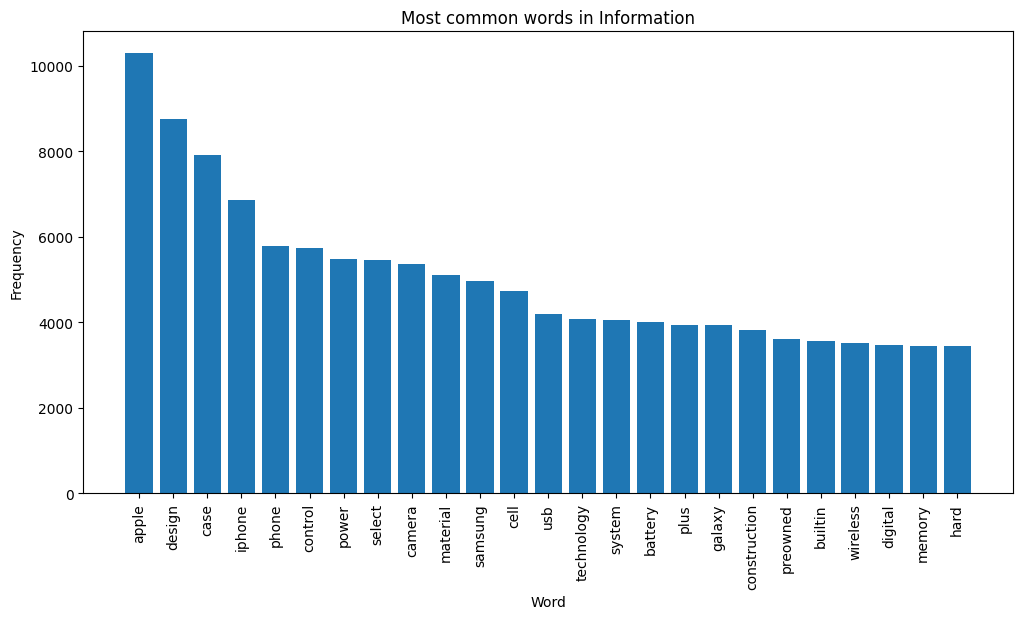

In [74]:
# Most common words in the 'Information' column
information_words = ' '.join(products_df['Information']).split()
information_word_counts = Counter(information_words)
top_information_words = information_word_counts.most_common(25)

# Extract words and frequencies
top_words, top_word_counts = zip(*top_information_words)

# Configure the figure
fig = plt.figure(figsize=(12, 6))

# Bar chart of the most common words in 'Information'
plt.bar(top_words, top_word_counts)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Most common words in Information')
plt.xticks(rotation=90)
plt.show()


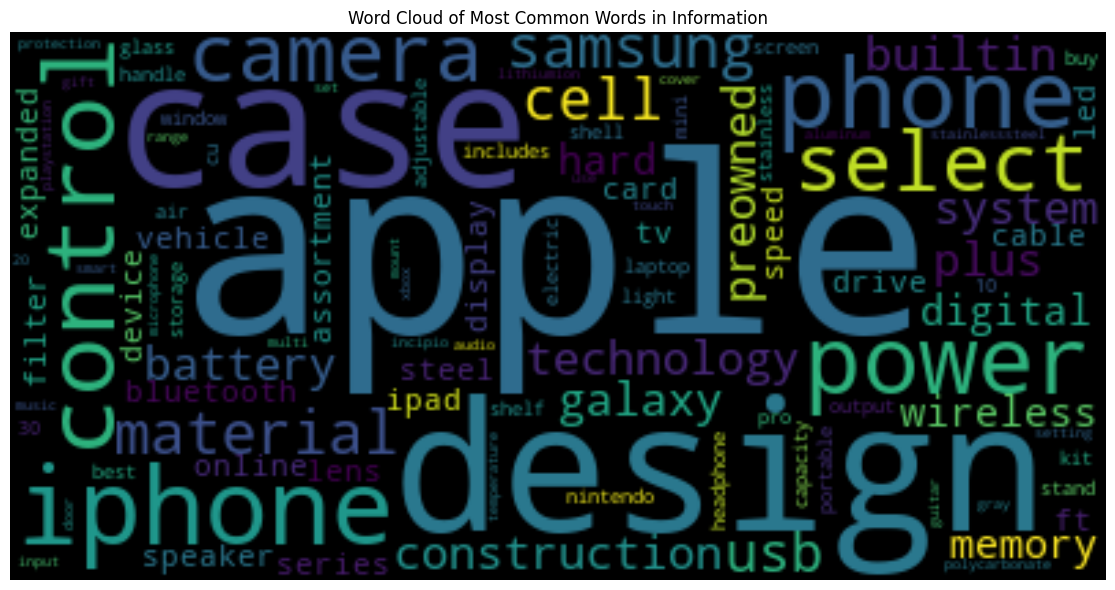

In [75]:
# Most common words in the 'Information' column
information_words = ' '.join(products_df['Information']).split()
information_word_counts = Counter(information_words)
top_information_words = information_word_counts.most_common(100)

# Create a WordCloud object for 'Information'
wordcloud_information = WordCloud().generate_from_frequencies(dict(top_information_words))

# Configure the figure
fig = plt.figure(figsize=(12, 6))

# Show the Word Cloud for 'Information'
plt.imshow(wordcloud_information, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Common Words in Information')

plt.tight_layout()
plt.show()


In [76]:
products_df.sample(5)

,Information,extracted_categories,characters_length,word_count
17368,apple refurbished iphone 64gb sprint refurbis...,"[Pre-Owned Games, Cell Phones]",193,24
28802,vornado 7503dc energy smart circulator fan ice...,"[Appliances, Heating, Cooling & Air Quality, F...",214,33
397,zildjian 18 zht crash ride cymbal bronze expan...,"[Drums & Percussion, Musical Instruments, Conn...",165,24
4749,hal leonard jamie cullum pursuit songbook mult...,"[Musical Instruments, Sheet Music, Sheet Music...",127,18
10972,calico design stiletto 3tier glass tv stand fl...,"[TV Stands, Mounts & Furniture, TV & Home Thea...",213,35


## 3. Classifier and accuracy research

Train classifiers that you feel best fit your needs, such as LightGBM, Xgboost, Catboot, RandomForest, Ensemble, and stacked variants. Additionally, train an MLP classifier.


Creating the new dataset to train with the columns to use

In [ ]:
# Seleccionar las columnas deseadas
selected_columns = ['Information', 'extracted_categories']
products_df = products_df[selected_columns].copy()

In [ ]:
# Exportar el DataFrame a un archivo CSV
products_df.to_csv('datos_limpios_tfidf.csv', index=False)

BERT

In [ ]:
!pip install transformers
!pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 40.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.2 MB/s eta 0:00:00


In [ ]:
!pip list

Package                          Version
-------------------------------- ---------------------
absl-py                          1.4.0
aiohttp                          3.8.5
aiosignal                        1.3.1
alabaster                        0.7.13
albumentations                   1.2.1
altair                           4.2.2
anyio                            3.7.1
appdirs                          1.4.4
argon2-cffi                      21.3.0
argon2-cffi-bindings             21.2.0
array-record                     0.4.0
arviz                            0.15.1
astropy                          5.2.2
astunparse                       1.6.3
async-timeout                    4.0.2
attrs                            23.1.0
audioread                        3.0.0
autograd                         1.6.2
Babel                            2.12.1
backcall                         0.2.0
beautifulsoup4                   4.11.2
bleach                           6.0.0
blinker                          1.4
bl

In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from torch.nn import BCEWithLogitsLoss
import torch.optim as optim

# Division of data into training and test sets
train_df, test_df = train_test_split(products_df, test_size=0.2, random_state=42)

# Category preprocessing
mlb = MultiLabelBinarizer()
train_categories = [set(categories) for categories in train_df['extracted_categories']]
test_categories = [set(categories) for categories in test_df['extracted_categories']]
encoded_train_categories = mlb.fit_transform(train_categories)
encoded_test_categories = mlb.transform(test_categories)

# Text tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_train_texts = tokenizer(list(train_df['Information']), padding=True, truncation=True, return_tensors='pt', max_length=128)
encoded_test_texts = tokenizer(list(test_df['Information']), padding=True, truncation=True, return_tensors='pt', max_length=128)

# BERT Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(mlb.classes_))

# DataLoader Definition
class CustomDataset(Dataset):
    def __init__(self, encoded_texts, encoded_categories):
        self.encoded_texts = encoded_texts
        self.encoded_categories = encoded_categories

    def __len__(self):
        return len(self.encoded_texts['input_ids'])

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encoded_texts.items()}, self.encoded_categories[idx]

train_dataset = CustomDataset(encoded_train_texts, encoded_train_categories)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = BCEWithLogitsLoss()

# Training cycle
for epoch in range(5):
    model.train()
    for batch_idx, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        inputs, targets = batch
        inputs = {key: val.to(device) for key, val in inputs.items()}
        targets = targets.to(device)
        outputs = model(**inputs).logits
        loss = criterion(outputs, targets.float())
        loss.backward()
        optimizer.step()

        # Print training progress
        print(f"Epoch [{epoch+1}/{5}], Batch [{batch_idx+1}/{len(train_dataloader)}], Loss: {loss.item():.4f}")

model.eval()
test_dataset = CustomDataset(encoded_test_texts, encoded_test_categories)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        inputs, labels = batch
        inputs = {key: val.to(device) for key, val in inputs.items()} 
        labels = labels.to(device)
        outputs = model(**inputs).logits
        predictions = torch.sigmoid(outputs) > 0.5
        all_predictions.extend(predictions)
        all_labels.extend(labels)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch [2/5], Batch [169/1292], Loss: 0.0562
Epoch [2/5], Batch [170/1292], Loss: 0.0512
Epoch [2/5], Batch [171/1292], Loss: 0.0582
Epoch [2/5], Batch [172/1292], Loss: 0.0587
Epoch [2/5], Batch [173/1292], Loss: 0.0530
Epoch [2/5], Batch [174/1292], Loss: 0.0601
Epoch [2/5], Batch [175/1292], Loss: 0.0522
Epoch [2/5], Batch [176/1292], Loss: 0.0591
Epoch [2/5], Batch [177/1292], Loss: 0.0564
Epoch [2/5], Batch [178/1292], Loss: 0.0549
Epoch [2/5], Batch [179/1292], Loss: 0.0533
Epoch [2/5], Batch [180/1292], Loss: 0.0526
Epoch [2/5], Batch [181/1292], Loss: 0.0543
Epoch [2/5], Batch [182/1292], Loss: 0.0516
Epoch [2/5], Batch [183/1292], Loss: 0.0515
Epoch [2/5], Batch [184/1292], Loss: 0.0580
Epoch [2/5], Batch [185/1292], Loss: 0.0531
Epoch [2/5], Batch [186/1292], Loss: 0.0512
Epoch [2/5], Batch [187/1292], Loss: 0.0556
Epoch [2/5], Batch [188/1292], Loss: 0.0556
Epoch [2/5], Batch [189/1292], Loss: 0.0525
Epoch [2/5], Ba

TypeError: ignored

In [ ]:
!pip install scikit-multilearn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 899.9 kB/s eta 0:00:00


In [ ]:
# Metric calculation
all_predictions_tensor = torch.stack(all_predictions_cpu)
all_labels_tensor = torch.stack(all_labels_cpu)

# Accuracy
correct = (all_predictions_tensor == all_labels_tensor).sum().item()
total = all_labels_tensor.numel()
accuracy = correct / total

# True Positives, False Positives, True Negatives, False Negatives
true_positives = ((all_predictions_tensor == 1) & (all_labels_tensor == 1)).sum().item()
false_positives = ((all_predictions_tensor == 1) & (all_labels_tensor == 0)).sum().item()
true_negatives = ((all_predictions_tensor == 0) & (all_labels_tensor == 0)).sum().item()
false_negatives = ((all_predictions_tensor == 0) & (all_labels_tensor == 1)).sum().item()

# Precision, recall, F1-score
precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


Accuracy: 0.994388122364889
Precision: 0.9478883400854653
Recall: 0.5343009979040886
F1-score: 0.6833913495778817


In [ ]:
# Get class names from MultiLabelBinarizer
class_names = mlb.classes_

# Calculation of metrics by class
for i, class_name in enumerate(class_names):
    true_positives = ((all_predictions_tensor[:, i] == 1) & (all_labels_tensor[:, i] == 1)).sum().item()
    false_positives = ((all_predictions_tensor[:, i] == 1) & (all_labels_tensor[:, i] == 0)).sum().item()
    true_negatives = ((all_predictions_tensor[:, i] == 0) & (all_labels_tensor[:, i] == 0)).sum().item()
    false_negatives = ((all_predictions_tensor[:, i] == 0) & (all_labels_tensor[:, i] == 1)).sum().item()

    # Precision, Recall, F1-score
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print all metrics on one line
    print(f"Class: {class_name} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")


Class: 3D Printer Filament | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: A/V Cables & Connectors | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Action Camcorder Accessories | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Action Camcorder Mounts | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Activity Trackers & Pedometers | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Adapters, Cables & Chargers | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Air Conditioners | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Air Purifier Filters & Parts | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: Air Purifiers | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: All Cell Phones with Plans | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: All Desktops | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Class: All Flat-Panel TVs | Precision: 0.0000 | Rec

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

#new_description = "Upgrade your home with this high-definition smart TV. Enjoy stunning visuals and vibrant colors on the big screen. Stream your favorite shows and movies with ease using built-in streaming apps. With voice control and smart home integration, it's the ultimate hub for all your entertainment needs."
#new_description = "Samsung Galaxy S21 Ultra - The latest flagship smartphone from Samsung, the Galaxy S21 Ultra, boasts a stunning 6.8-inch Dynamic AMOLED display with a 120Hz refresh rate for smooth scrolling and gaming. Powered by the Exynos 2100 or Snapdragon 888 processor, it offers blazing-fast performance and supports 5G connectivity. The S21 Ultra features a versatile quad-camera setup with a 108MP main sensor, two telephoto lenses, and an ultra-wide lens, enabling users to capture professional-grade photos and 8K videos. With a massive 5,000mAh battery and fast charging support, the Galaxy S21 Ultra ensures all-day usage without worrying about battery life. Its premium design, water and dust resistance, and S Pen compatibility make it a top choice for tech enthusiasts and power users"
#new_description = "Its Magic Keyboard ensures a comfortable typing experience, and the large Force Touch trackpad allows for precise cursor control. The laptop also features a studio-quality three-microphone array and powerful speakers for immersive audio and video conferencing. Whether you're a student, a professional, or a creative enthusiast, the MacBook Pro 13-inch is a top-tier choice for productivity and creativity on the go."
#new_description = "Logitech MX Master 3 - Take control of your workflow with the Logitech MX Master 3 wireless mouse. This advanced mouse is designed for productivity and precision, featuring customizable buttons and a high-precision Darkfield sensor that tracks on any surface, even glass. "
new_description = "iPhone 13 - The latest model of Apple's iconic smartphone, featuring a faster processor, improved camera capabilities, and longer battery life."
#new_description = "Samsung Galaxy Watch - A stylish and feature-rich smartwatch that tracks your fitness activities, monitors your heart rate, and allows you to receive notifications from your smartphone."
#new_description = "Fitbit Charge 4 Fitness Tracker - Stay on top of your fitness goals with this advanced fitness tracker. It tracks your heart rate, steps, sleep, and more, helping you maintain a healthy lifestyle."
#new_description = "Samsung 55-inch 4K Smart TV - Immerse yourself in stunning 4K visuals and access a world of entertainment with this smart TV from Samsung. With its large screen and advanced features, it's the perfect addition to your home theater setup."
#new_description ="Sony Noise-Cancelling Headphones - Immerse yourself in your favorite music or podcasts with these high-quality noise-cancelling headphones from Sony. With their comfortable design and superior sound quality, you can enjoy a truly immersive audio experience wherever you go."
#new_description = "Compact wireless earbuds with noise-cancelling technology."
#new_description = "High-definition smart TV with voice control and streaming capabilities."
#new_description = "Compact and portable Bluetooth speaker with powerful sound and built-in microphone for hands-free calls."
#new_description = "High-definition 4K action camera with waterproof case and multiple mounting options for capturing all your adventurous moments."
#new_description = "Powerful gaming laptop with a high-performance processor and cutting-edge graphics for an unparalleled gaming experience."
#new_description = "High-performance gaming mouse with customizable RGB lighting, programmable buttons, and adjustable DPI settings for precise control and smooth gameplay."
#new_description = "Compact and portable Bluetooth speaker with excellent sound quality, long battery life, and built-in microphone for hands-free calls."
#new_description = "EcoBreeze USB-Powered Personal Fan - Stay cool and refreshed wherever you go with the EcoBreeze USB-Powered Personal Fan. This compact and portable fan is powered by a USB connection, making it compatible with your laptop, power bank, or any USB outlet. With its adjustable airflow settings, you can customize the breeze to your liking, providing instant relief from hot days or stuffy environments. The lightweight design and foldable stand make it easy to carry and position, ensuring you stay comfortable during outdoor activities, work, or relaxation. Embrace the EcoBreeze USB-Powered Personal Fan for a breath of fresh air on demand."
#new_prediction_text = "EcoCycle Recycled Backpack-Embrace sustainability with the EcoCycle Recycled Backpack. This eco-conscious accessory is crafted from recycled materials, reducing waste and supporting a greener future. The backpack features multiple compartments, padded shoulder straps, and a laptop sleeve, making it ideal for work, school, or travel. With its durable construction and stylish design, the EcoCycle Recycled Backpack not only helps you carry your essentials but also makes a positive impact on the environment. Choose eco-friendly fashion and make a statement for a more sustainable world with the EcoCycle Recycled Backpack"

new_prediction_tokenized = tokenizer(new_description, padding=True, truncation=True, return_tensors='pt', max_length=128)

# Move tensors to GPU if you are using CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
new_prediction_tokenized = {key: val.to(device) for key, val in new_prediction_tokenized.items()}

# Get model outputs
with torch.no_grad():
    model.eval()
    new_prediction_outputs = model(**new_prediction_tokenized)

# Define initial threshold
threshold = 0.5

# Iterate until a category is found or the threshold is halved
while True:
    # Apply threshold to get binary predictions
    new_prediction_labels = (torch.sigmoid(new_prediction_outputs.logits) > threshold).cpu().numpy()

    # Interpret the predictions (replace with your own classes and labels)
    predicted_labels = mlb.classes_[new_prediction_labels[0]]

    if len(predicted_labels) > 0:
        predicted_labels
        break
    else:
        threshold /= 2

print("Predicted categories:", predicted_labels)


Categorías predichas: ['Cell Phones']


In [ ]:
import torch

# Save the model to a file
model_path = 'modelo_bert.pth'
torch.save(model.state_dict(), model_path)

Implementing a MultiOutputClassifier with LogisticRegression, using a CountVectorizer

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import average_precision_score, f1_score
from sklearn.metrics import classification_report

products_df_filtered = products_df

# Separate data into features (X) and labels (y)
X = products_df_filtered['Information']
y = products_df_filtered['extracted_categories']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a multi-label classification model using Logistic Regression
model = MultiOutputClassifier(LogisticRegression(class_weight='balanced'))

# Create an instance of CountVectorizer to convert text to numeric features
vectorizer = CountVectorizer()

# Convert text to numeric features for the training set
X_train_vectorized = vectorizer.fit_transform(X_train)

# Convert the labels to a binary array for the training set
mlb = MultiLabelBinarizer()
y_train_bin = mlb.fit_transform(y_train)

# Train the model with the training data
model.fit(X_train_vectorized, y_train_bin)

# Convert text to numeric features for test set
X_test_vectorized = vectorizer.transform(X_test)

# Predict the labels in the test set
y_pred_bin = model.predict(X_test_vectorized)

# Convert the actual labels of the test set to a binary array
y_test_bin = mlb.transform(y_test)

# Calculate Average Precision and F1 Score per class
avg_precision = average_precision_score(y_test_bin, y_pred_bin, average='micro')
f1_per_class = f1_score(y_test_bin, y_pred_bin, average=None)

print(f'Average Precision: {avg_precision:.2f}')

class_names = mlb.classes_
classification_rep = classification_report(y_test_bin, y_pred_bin, target_names=class_names)

print("F1-score report by class:")
print(classification_rep)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Average Precision: 0.84
Informe de F1-score por clase:
                                           precision    recall  f1-score   support

                      3D Printer Filament       0.96      0.98      0.97        51
                  A/V Cables & Connectors       0.89      0.80      0.84        88
             Action Camcorder Accessories       0.78      0.58      0.67        48
                  Action Camcorder Mounts       0.85      0.68      0.75        34
           Activity Trackers & Pedometers       0.94      0.94      0.94        54
              Adapters, Cables & Chargers       0.92      0.81      0.86       127
                         Air Conditioners       1.00      0.90      0.95        29
             Air Purifier Filters & Parts       1.00      0.90      0.95        21
                            Air Purifiers       1.00      0.87      0.93        30
               All Cell Phones with Plans       0.97      0.94      0.95        33
                             Al

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


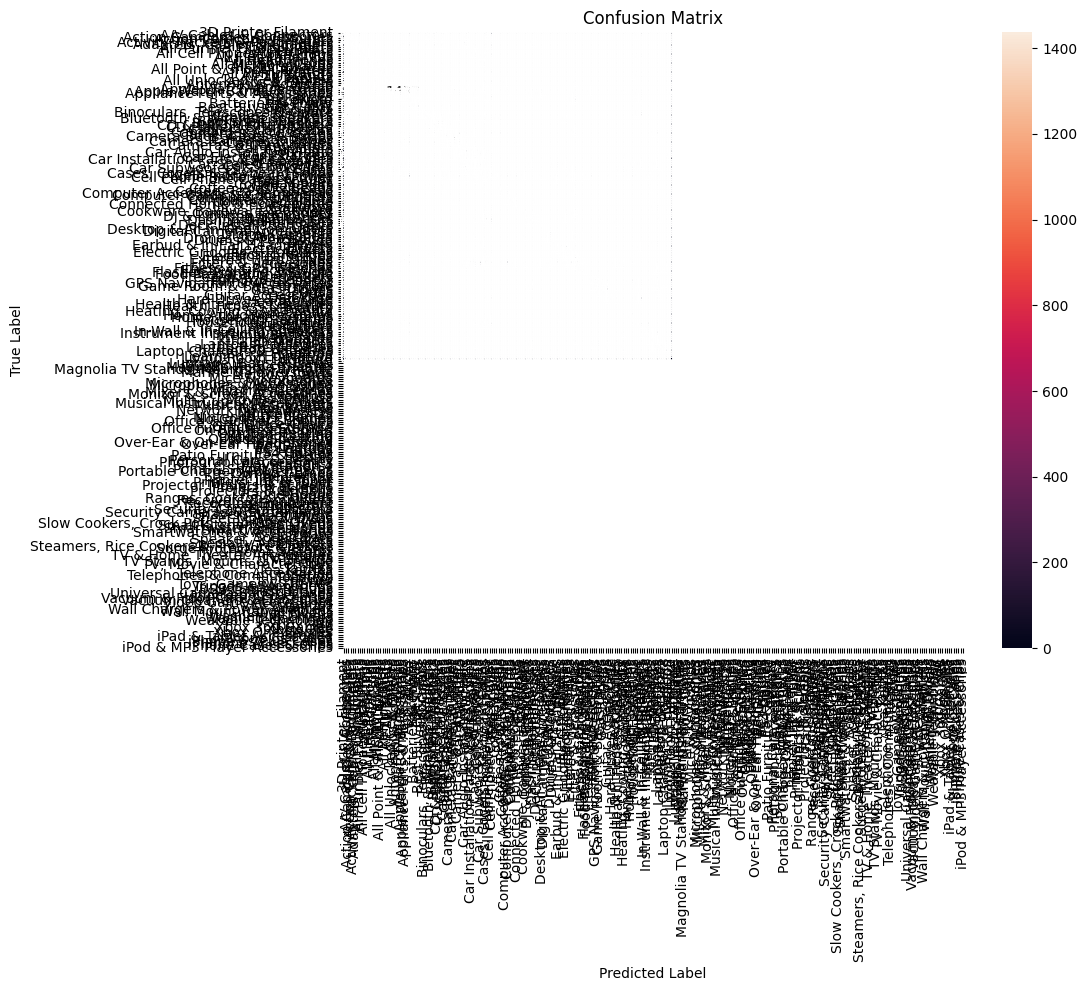

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_bin.argmax(axis=1), y_pred_bin.argmax(axis=1))

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


EXAMPLE NEW PREDICTIONS

In [ ]:

# New description to classify
#new_description = "Upgrade your home with this high-definition smart TV. Enjoy stunning visuals and vibrant colors on the big screen. Stream your favorite shows and movies with ease using built-in streaming apps. With voice control and smart home integration, it's the ultimate hub for all your entertainment needs."
#new_description = "Samsung Galaxy S21 Ultra - The latest flagship smartphone from Samsung, the Galaxy S21 Ultra, boasts a stunning 6.8-inch Dynamic AMOLED display with a 120Hz refresh rate for smooth scrolling and gaming. Powered by the Exynos 2100 or Snapdragon 888 processor, it offers blazing-fast performance and supports 5G connectivity. The S21 Ultra features a versatile quad-camera setup with a 108MP main sensor, two telephoto lenses, and an ultra-wide lens, enabling users to capture professional-grade photos and 8K videos. With a massive 5,000mAh battery and fast charging support, the Galaxy S21 Ultra ensures all-day usage without worrying about battery life. Its premium design, water and dust resistance, and S Pen compatibility make it a top choice for tech enthusiasts and power users"
#new_description = "Its Magic Keyboard ensures a comfortable typing experience, and the large Force Touch trackpad allows for precise cursor control. The laptop also features a studio-quality three-microphone array and powerful speakers for immersive audio and video conferencing. Whether you're a student, a professional, or a creative enthusiast, the MacBook Pro 13-inch is a top-tier choice for productivity and creativity on the go."
#new_description = "Logitech MX Master 3 - Take control of your workflow with the Logitech MX Master 3 wireless mouse. This advanced mouse is designed for productivity and precision, featuring customizable buttons and a high-precision Darkfield sensor that tracks on any surface, even glass. "
#new_description = "iPhone 13 - The latest model of Apple's iconic smartphone, featuring a faster processor, improved camera capabilities, and longer battery life."
#new_description = "Samsung Galaxy Watch - A stylish and feature-rich smartwatch that tracks your fitness activities, monitors your heart rate, and allows you to receive notifications from your smartphone."
#new_description = "Fitbit Charge 4 Fitness Tracker - Stay on top of your fitness goals with this advanced fitness tracker. It tracks your heart rate, steps, sleep, and more, helping you maintain a healthy lifestyle."
#new_description = "Samsung 55-inch 4K Smart TV - Immerse yourself in stunning 4K visuals and access a world of entertainment with this smart TV from Samsung. With its large screen and advanced features, it's the perfect addition to your home theater setup."
#new_description ="Sony Noise-Cancelling Headphones - Immerse yourself in your favorite music or podcasts with these high-quality noise-cancelling headphones from Sony. With their comfortable design and superior sound quality, you can enjoy a truly immersive audio experience wherever you go."
#new_description = "Compact wireless earbuds with noise-cancelling technology."
#new_description = "High-definition smart TV with voice control and streaming capabilities."
#new_description = "Compact and portable Bluetooth speaker with powerful sound and built-in microphone for hands-free calls."
#new_description = "High-definition 4K action camera with waterproof case and multiple mounting options for capturing all your adventurous moments."
#new_description = "Powerful gaming laptop with a high-performance processor and cutting-edge graphics for an unparalleled gaming experience."
#new_description = "High-performance gaming mouse with customizable RGB lighting, programmable buttons, and adjustable DPI settings for precise control and smooth gameplay."
#new_description = "Compact and portable Bluetooth speaker with excellent sound quality, long battery life, and built-in microphone for hands-free calls."
new_description = "EcoBreeze USB-Powered Personal Fan - Stay cool and refreshed wherever you go with the EcoBreeze USB-Powered Personal Fan. This compact and portable fan is powered by a USB connection, making it compatible with your laptop, power bank, or any USB outlet. With its adjustable airflow settings, you can customize the breeze to your liking, providing instant relief from hot days or stuffy environments. The lightweight design and foldable stand make it easy to carry and position, ensuring you stay comfortable during outdoor activities, work, or relaxation. Embrace the EcoBreeze USB-Powered Personal Fan for a breath of fresh air on demand."

# Preprocess the new description
new_description_vectorized = vectorizer.transform([new_description])

# Make prediction
new_description_pred_bin = model.predict(new_description_vectorized)

# Convert prediction to actual categories
new_description_categories = mlb.inverse_transform(new_description_pred_bin)

# If no category was predicted, find the most similar label based on cosine similarity
if not new_description_categories[0]:
    # Calculate the cosine similarity between the new description and the existing categories
    similarity_scores = cosine_similarity(new_description_vectorized, X_train_vectorized)

    # Find the most similar category based on similarity
    most_similar_idx = np.argmax(similarity_scores)
    most_similar_label = y_train.iloc[most_similar_idx]

    new_description_categories = [tuple([most_similar_label])]

print("Predicted categories for the new description:")
print(new_description_categories)


Categorías predichas para la nueva descripción:
[('Appliances', 'Computers & Tablets', 'Fans', 'Heating, Cooling & Air Quality')]


Implementing a MultiOutputClassifier with LogisticRegression, using a TFIDF, GridSearchCV to select the best model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import average_precision_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

products_df_filtered = products_df

# Separate data into features (X) and labels (y)
X = products_df_filtered['Information']
y = products_df_filtered['extracted_categories']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of TfidfVectorizer with the desired parameters
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, ngram_range=(1, 1), sublinear_tf=True)

# Convert text to numeric features for the training set
X_train_vectorized = vectorizer.fit_transform(X_train)

# Convert the labels to a binary array for the training set
mlb = MultiLabelBinarizer()
y_train_bin = mlb.fit_transform(y_train)

# Create a multi-label classification model using Logistic Regression
model = MultiOutputClassifier(LogisticRegression(class_weight='balanced', max_iter=2000))

# Define possible values for hyperparameters
param_grid = {
    'estimator__C': [0.01, 1, 10],
    'estimator__penalty': ['l1', 'l2']
}

# Perform grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_micro')
grid_search.fit(X_train_vectorized, y_train_bin)

# Get the best model with the best hyperparameters
best_model = grid_search.best_estimator_

# Convert text to numeric features for test set
X_test_vectorized = vectorizer.transform(X_test)

# Predict the labels in the test set
y_pred_bin = best_model.predict(X_test_vectorized)

# Convert the actual labels of the test set to a binary array
y_test_bin = mlb.transform(y_test)

# Calculate Average Precision and F1 Score per class
avg_precision = average_precision_score(y_test_bin, y_pred_bin, average='micro')
f1_per_class = f1_score(y_test_bin, y_pred_bin, average=None)

print(f'Average Precision: {avg_precision:.2f}')

class_names = mlb.classes_
classification_rep = classification_report(y_test_bin, y_pred_bin, target_names=class_names)

print("F1-score report by class:")
print(classification_rep)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/multioutput.py", line 450, in fit
    super().fit(X, Y, sample_weight, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/multioutput.py", line 216, in fit
    self.estimators_ = Parallel(n_jobs=self.n_jobs)(
  File "/usr/local/lib/python3.1

Average Precision: 0.83
Informe de F1-score por clase:
                                           precision    recall  f1-score   support

                      3D Printer Filament       0.93      1.00      0.96        51
                  A/V Cables & Connectors       0.75      0.89      0.81        88
             Action Camcorder Accessories       0.66      0.88      0.75        48
                  Action Camcorder Mounts       0.60      0.94      0.74        34
           Activity Trackers & Pedometers       0.87      0.98      0.92        54
              Adapters, Cables & Chargers       0.73      0.93      0.82       127
                         Air Conditioners       1.00      1.00      1.00        29
             Air Purifier Filters & Parts       0.81      1.00      0.89        21
                            Air Purifiers       0.79      1.00      0.88        30
               All Cell Phones with Plans       0.79      1.00      0.88        33
                             Al

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import pickle

# Save the model to a pickle file
with open('model_tfidf.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

# Save the vectorizer to a pickle file
with open('vectorizer_tfidf.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

# Save the mlb to a pickle file
with open('mlb_tfidf.pkl', 'wb') as binarizer_file:
    pickle.dump(mlb, binarizer_file)

# Save the X_train_vectorized to a pickle file
with open('X_train_vectorized_tfidf.pkl', 'wb') as f:
    pickle.dump(X_train_vectorized, f)

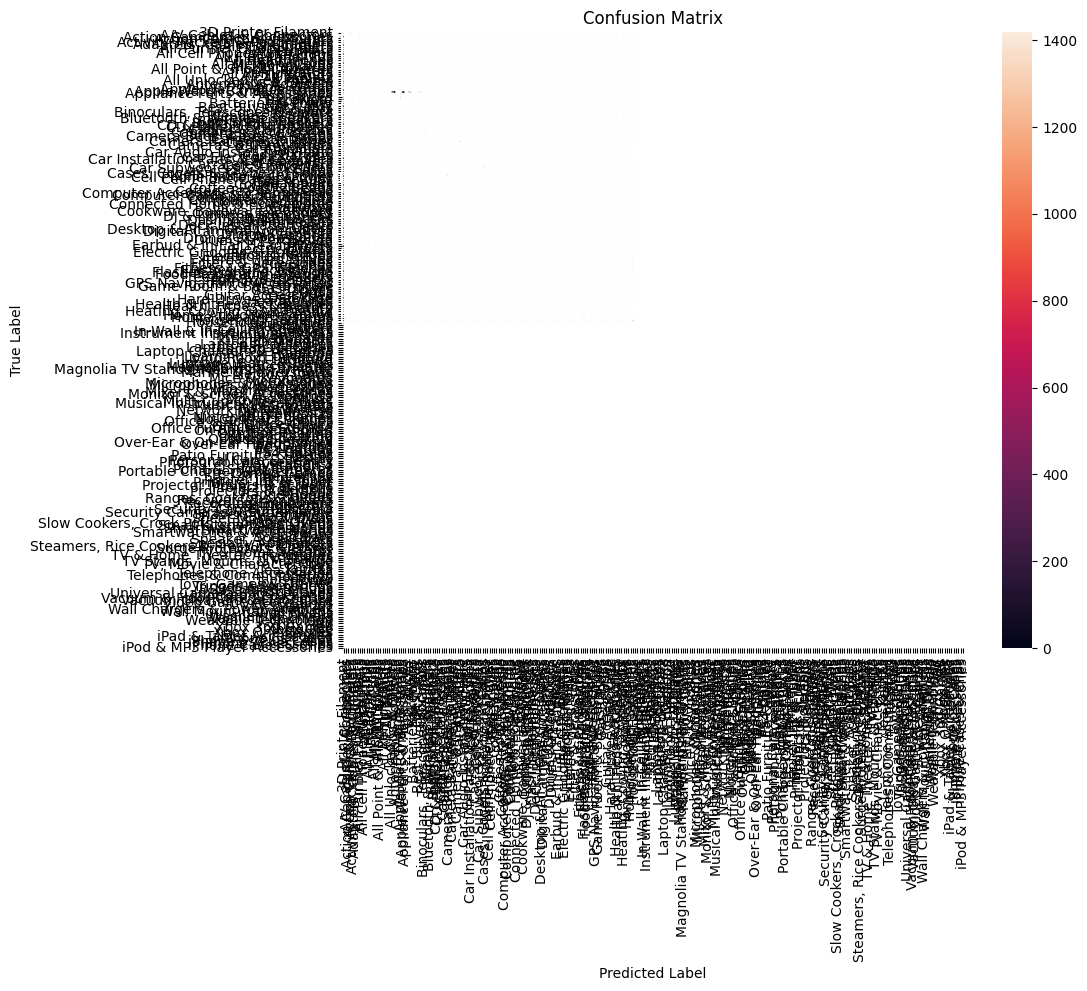

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_bin.argmax(axis=1), y_pred_bin.argmax(axis=1))

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import numpy as np

# New description to classify
new_description = "Upgrade your home with this high-definition smart TV. Enjoy stunning visuals and vibrant colors on the big screen. Stream your favorite shows and movies with ease using built-in streaming apps. With voice control and smart home integration, it's the ultimate hub for all your entertainment needs."
#new_description = "Samsung Galaxy S21 Ultra - The latest flagship smartphone from Samsung, the Galaxy S21 Ultra, boasts a stunning 6.8-inch Dynamic AMOLED display with a 120Hz refresh rate for smooth scrolling and gaming. Powered by the Exynos 2100 or Snapdragon 888 processor, it offers blazing-fast performance and supports 5G connectivity. The S21 Ultra features a versatile quad-camera setup with a 108MP main sensor, two telephoto lenses, and an ultra-wide lens, enabling users to capture professional-grade photos and 8K videos. With a massive 5,000mAh battery and fast charging support, the Galaxy S21 Ultra ensures all-day usage without worrying about battery life. Its premium design, water and dust resistance, and S Pen compatibility make it a top choice for tech enthusiasts and power users"
#new_description = "Its Magic Keyboard ensures a comfortable typing experience, and the large Force Touch trackpad allows for precise cursor control. The laptop also features a studio-quality three-microphone array and powerful speakers for immersive audio and video conferencing. Whether you're a student, a professional, or a creative enthusiast, the MacBook Pro 13-inch is a top-tier choice for productivity and creativity on the go."
#new_description = "Logitech MX Master 3 - Take control of your workflow with the Logitech MX Master 3 wireless mouse. This advanced mouse is designed for productivity and precision, featuring customizable buttons and a high-precision Darkfield sensor that tracks on any surface, even glass. "
#new_description = "iPhone 13 - The latest model of Apple's iconic smartphone, featuring a faster processor, improved camera capabilities, and longer battery life."
#new_description = "Samsung Galaxy Watch - A stylish and feature-rich smartwatch that tracks your fitness activities, monitors your heart rate, and allows you to receive notifications from your smartphone."
#new_description = "Fitbit Charge 4 Fitness Tracker - Stay on top of your fitness goals with this advanced fitness tracker. It tracks your heart rate, steps, sleep, and more, helping you maintain a healthy lifestyle."
#new_description = "Samsung 55-inch 4K Smart TV - Immerse yourself in stunning 4K visuals and access a world of entertainment with this smart TV from Samsung. With its large screen and advanced features, it's the perfect addition to your home theater setup."
#new_description ="Sony Noise-Cancelling Headphones - Immerse yourself in your favorite music or podcasts with these high-quality noise-cancelling headphones from Sony. With their comfortable design and superior sound quality, you can enjoy a truly immersive audio experience wherever you go."
#new_description = "Compact wireless earbuds with noise-cancelling technology."
#new_description = "High-definition smart TV with voice control and streaming capabilities."
#new_description = "Compact and portable Bluetooth speaker with powerful sound and built-in microphone for hands-free calls."
#new_description = "High-definition 4K action camera with waterproof case and multiple mounting options for capturing all your adventurous moments."
#new_description = "Powerful gaming laptop with a high-performance processor and cutting-edge graphics for an unparalleled gaming experience."
#new_description = "High-performance gaming mouse with customizable RGB lighting, programmable buttons, and adjustable DPI settings for precise control and smooth gameplay."
#new_description = "Compact and portable Bluetooth speaker with excellent sound quality, long battery life, and built-in microphone for hands-free calls."
#new_description = "EcoBreeze USB-Powered Personal Fan - Stay cool and refreshed wherever you go with the EcoBreeze USB-Powered Personal Fan. This compact and portable fan is powered by a USB connection, making it compatible with your laptop, power bank, or any USB outlet. With its adjustable airflow settings, you can customize the breeze to your liking, providing instant relief from hot days or stuffy environments. The lightweight design and foldable stand make it easy to carry and position, ensuring you stay comfortable during outdoor activities, work, or relaxation. Embrace the EcoBreeze USB-Powered Personal Fan for a breath of fresh air on demand."

# Preprocess the new description
new_description_vectorized = vectorizer.transform([new_description])

# Make prediction
new_description_pred_bin = best_model.predict(new_description_vectorized)

# Convert prediction to actual categories
new_description_categories = mlb.inverse_transform(new_description_pred_bin)

# If no category was predicted, since they did not exceed the threshold of 0.5, search and return the label with the highest probability for that prediction.
if not new_description_categories[0]:
    # Get the probabilities predicted by the model
    predicted_probs = best_model.predict_proba(new_description_vectorized)

    # Convert predicted_probs to a NumPy array
    predicted_probs_array = np.array(predicted_probs)

    # Select the probabilities of the positive class for each category
    positive_probs = predicted_probs_array[:, :, 1]

    # Find the category with the highest probability
    most_probable_label_idx = np.argmax(positive_probs)
    most_probable_label = mlb.classes_[most_probable_label_idx]

    new_description_categories = [tuple([most_probable_label])]

print("Predicted categories for the new description:")
print(new_description_categories)


Categorías predichas para la nueva descripción:
[('Connected Home & Housewares', 'TV & Home Theater')]
